<a href="https://colab.research.google.com/github/smriithhii/nlpr/blob/main/nlpr_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **data cleaning**

In [ ]:
import pandas as pd
import re

file_path1 = "dataset/3_Student depression and anxiety dataset.xlsx"
file_path2 = "dataset/1_depression_dataset_reddit_cleaned.csv"
file_path3 = "dataset/2_Stress.csv"
file_path4 = "dataset/4_Suicide_Ideation_Dataset.csv"

df1 = pd.read_excel(file_path1)
df2 = pd.read_csv(file_path2)
df3 = pd.read_csv(file_path3)
df4 = pd.read_csv(file_path4, encoding='latin1')

def clean_text(text):
    """Clean text: lowercase, remove URLs, punctuation, numbers, and extra spaces."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_dataset(df, text_col='text', label_col='label'):
    """Clean dataset safely and drop rows with missing/empty text or labels."""
    df_temp = df.copy()

    actual_text_col = text_col if text_col in df_temp.columns else df_temp.columns[0]
    actual_label_col = label_col if label_col in df_temp.columns else None

    if not actual_label_col:
        print(f"⚠️ Warning: '{label_col}' column not found, skipping label processing.")

    df_temp['cleaned_text'] = df_temp[actual_text_col].apply(clean_text)

    if actual_label_col:
        df_temp = df_temp.dropna(subset=[actual_text_col, actual_label_col])
        df_temp = df_temp[df_temp[actual_text_col].astype(str).str.strip() != '']
        df_temp = df_temp[df_temp[actual_label_col].astype(str).str.strip() != '']
        cleaned_df = df_temp[[actual_label_col, 'cleaned_text']]
    else:
        df_temp = df_temp.dropna(subset=[actual_text_col])
        df_temp = df_temp[df_temp[actual_text_col].astype(str).str.strip() != '']
        cleaned_df = df_temp[['cleaned_text']]

    print(f"✅ Cleaned {len(cleaned_df)} rows in {label_col if label_col else 'dataset without label'}")
    return cleaned_df

print("Cleaning Dataset 1:")
df1_cleaned = clean_dataset(df1)

print("\nCleaning Dataset 2:")
df2_cleaned = clean_dataset(df2, text_col='clean_text', label_col='is_depression')

print("\nCleaning Dataset 3:")
df3_cleaned = clean_dataset(df3, text_col='text', label_col='label')

print("\nCleaning Dataset 4:")
df4_cleaned = clean_dataset(df4, text_col='Tweet', label_col='Suicide')

df4_cleaned['Suicide'] = df4_cleaned['Suicide'].apply(lambda x: 0 if str(x).strip().lower() == 'not suicide post' else 1)

df1_cleaned.to_csv("dataset/cleaned/dataset1.csv", index=False)
df2_cleaned.to_csv("dataset/cleaned/dataset2.csv", index=False)
df3_cleaned.to_csv("dataset/cleaned/dataset3.csv", index=False)
df4_cleaned.to_csv("dataset/cleaned/dataset4.csv", index=False)

print("\n🎯 All cleaned datasets saved successfully!")

Cleaning Dataset 1:
✅ Cleaned 6970 rows in label

Cleaning Dataset 2:
✅ Cleaned 7731 rows in is_depression

Cleaning Dataset 3:
✅ Cleaned 2838 rows in label

Cleaning Dataset 4:
✅ Cleaned 1785 rows in Suicide

🎯 All cleaned datasets saved successfully!


#Down Sampling

checking

In [ ]:
import pandas as pd

paths = {
    "dataset1": "dataset/cleaned/dataset1.csv",
    "dataset2": "dataset/cleaned/dataset2.csv",
    "dataset3": "dataset/cleaned/dataset3.csv",
    "dataset4": "dataset/cleaned/dataset4.csv"
}

def downsample_dataset(df, n=1300, label_col=None):
    if label_col and label_col in df.columns:
        df_down = (
            df.groupby(label_col, group_keys=False)
              .apply(lambda x: x.sample(
                  min(len(x), n // df[label_col].nunique()),
                  random_state=42))
              .reset_index(drop=True)
        )
    else:
        df_down = df.sample(n=min(len(df), n), random_state=42).reset_index(drop=True)
    return df_down

for name, path in paths.items():
    df = pd.read_csv(path)

    possible_labels = ['label', 'is_depression', 'Suicide']
    label_col = next((col for col in possible_labels if col in df.columns), None)

    df_down = downsample_dataset(df, n=1300, label_col=label_col)

    if 'is_depression' in df_down.columns:
        df_down.rename(columns={'is_depression': 'label'}, inplace=True)

    if 'Suicide' in df_down.columns:
        df_down.rename(columns={'Suicide': 'label'}, inplace=True)

    out_path = f"dataset/Downsampled/{name}_downsampled.csv"
    df_down.to_csv(out_path, index=False)

    print(f"✅ {name} downsampled to {len(df_down)} rows → saved at: {out_path}")

/tmp/ipython-input-2860594209.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/tmp/ipython-input-2860594209.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/tmp/ipython-input-2860594209.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping 

✅ dataset1 downsampled to 1300 rows → saved at: /content/drive/MyDrive/nlpr/Downsampled/dataset1_downsampled.csv
✅ dataset2 downsampled to 1300 rows → saved at: /content/drive/MyDrive/nlpr/Downsampled/dataset2_downsampled.csv
✅ dataset3 downsampled to 1300 rows → saved at: /content/drive/MyDrive/nlpr/Downsampled/dataset3_downsampled.csv
✅ dataset4 downsampled to 1300 rows → saved at: /content/drive/MyDrive/nlpr/Downsampled/dataset4_downsampled.csv


/tmp/ipython-input-2860594209.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


# Data augumentation

data mapping

In [ ]:
dataset_mapping = {
    "dataset1": "d1",
    "dataset2": "d2",
    "dataset3": "d3",
    "dataset4": "d4"
}

In [ ]:
import pandas as pd
import torch
from transformers import pipeline
import random
import os

BERT-25

In [ ]:
device = 0 if torch.cuda.is_available() else -1

unmasker = pipeline('fill-mask', model='bert-base-uncased', device=device)

def augment_text_bert(text, num_augments=1):
    words = text.split()
    if len(words) < 3:
        return [text] * num_augments

    augmented_texts = []

    for _ in range(num_augments):
        num_masks = max(1, int(len(words) * 0.15))
        mask_positions = random.sample(range(len(words)), min(num_masks, len(words)))

        masked_text = words.copy()
        for pos in mask_positions:
            masked_text[pos] = '[MASK]'

        masked_sentence = ' '.join(masked_text)

        try:
            predictions = unmasker(masked_sentence)

            if isinstance(predictions[0], list):
                predictions = predictions[0]

            new_words = words.copy()
            for pos in mask_positions:
                new_words[pos] = predictions[0]['token_str'].strip()

            augmented_texts.append(' '.join(new_words))
        except:
            augmented_texts.append(text)

    return augmented_texts

def augment_dataset_bert(df, text_col='cleaned_text', label_col=None, aug_ratio=0.25):
    num_to_augment = int(len(df) * aug_ratio)

    sample_indices = random.sample(range(len(df)), num_to_augment)

    augmented_rows = []

    for idx in sample_indices:
        original_text = df.iloc[idx][text_col]
        augmented_text = augment_text_bert(original_text, num_augments=1)[0]

        new_row = df.iloc[idx].copy()
        new_row[text_col] = augmented_text
        augmented_rows.append(new_row)

    augmented_df = pd.DataFrame(augmented_rows)
    result_df = pd.concat([df, augmented_df], ignore_index=True)

    return result_df

paths = {
    "dataset1": "dataset/Downsampled/dataset1_downsampled.csv",
    "dataset2": "dataset/Downsampled/dataset2_downsampled.csv",
    "dataset3": "dataset/Downsampled/dataset3_downsampled.csv",
    "dataset4": "dataset/Downsampled/dataset4_downsampled.csv"
}

for name, path in paths.items():
    df = pd.read_csv(path)

    possible_labels = ['label', 'is_depression', 'Suicide']
    label_col = next((col for col in possible_labels if col in df.columns), None)

    dataset_prefix = dataset_mapping[name]

    print(f"Processing {name} for 25% BERT augmentation...")
    df_aug_25 = augment_dataset_bert(df, text_col='cleaned_text', label_col=label_col, aug_ratio=0.25)
    out_path_25 = f"dataset/data_augumentation/bert/25/{dataset_prefix}_bert_25.csv"
    df_aug_25.to_csv(out_path_25, index=False)
    print(f"[SUCCESS] {name} augmented to {len(df_aug_25)} rows (25%) -> saved at: {out_path_25}")

    print(f"Processing {name} for 50% BERT augmentation...")
    df_aug_50 = augment_dataset_bert(df, text_col='cleaned_text', label_col=label_col, aug_ratio=0.50)
    out_path_50 = f"dataset/data_augumentation/bert/50/{dataset_prefix}_bert_50.csv"
    df_aug_50.to_csv(out_path_50, index=False)
    print(f"[SUCCESS] {name} augmented to {len(df_aug_50)} rows (50%) -> saved at: {out_path_50}")

print("\nAll datasets augmented with BERT (25% and 50%)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if 

Processing dataset1 for 25% BERT augmentation...
[SUCCESS] dataset1 augmented to 1625 rows (25%) -> saved at: /content/drive/MyDrive/nlpr/data_augumentation/bert/25/d1_bert_25.csv
Processing dataset1 for 50% BERT augmentation...
[SUCCESS] dataset1 augmented to 1950 rows (50%) -> saved at: /content/drive/MyDrive/nlpr/data_augumentation/bert/50/d1_bert_50.csv
Processing dataset2 for 25% BERT augmentation...


Token indices sequence length is longer than the specified maximum sequence length for this model (538 > 512). Running this sequence through the model will result in indexing errors


[SUCCESS] dataset2 augmented to 1625 rows (25%) -> saved at: /content/drive/MyDrive/nlpr/data_augumentation/bert/25/d2_bert_25.csv
Processing dataset2 for 50% BERT augmentation...
[SUCCESS] dataset2 augmented to 1950 rows (50%) -> saved at: /content/drive/MyDrive/nlpr/data_augumentation/bert/50/d2_bert_50.csv
Processing dataset3 for 25% BERT augmentation...
[SUCCESS] dataset3 augmented to 1625 rows (25%) -> saved at: /content/drive/MyDrive/nlpr/data_augumentation/bert/25/d3_bert_25.csv
Processing dataset3 for 50% BERT augmentation...
[SUCCESS] dataset3 augmented to 1950 rows (50%) -> saved at: /content/drive/MyDrive/nlpr/data_augumentation/bert/50/d3_bert_50.csv
Processing dataset4 for 25% BERT augmentation...
[SUCCESS] dataset4 augmented to 1625 rows (25%) -> saved at: /content/drive/MyDrive/nlpr/data_augumentation/bert/25/d4_bert_25.csv
Processing dataset4 for 50% BERT augmentation...
[SUCCESS] dataset4 augmented to 1950 rows (50%) -> saved at: /content/drive/MyDrive/nlpr/data_augume

Back translation

In [ ]:
import pandas as pd
from transformers import MarianMTModel, MarianTokenizer
import random



In [ ]:
model_name_en_to_fr = 'Helsinki-NLP/opus-mt-en-fr'
model_name_fr_to_en = 'Helsinki-NLP/opus-mt-fr-en'

tokenizer_en_fr = MarianTokenizer.from_pretrained(model_name_en_to_fr)
model_en_fr = MarianMTModel.from_pretrained(model_name_en_to_fr)

tokenizer_fr_en = MarianTokenizer.from_pretrained(model_name_fr_to_en)
model_fr_en = MarianMTModel.from_pretrained(model_name_fr_to_en)

def augment_text_backtranslation(text):
    try:
        inputs = tokenizer_en_fr(text, return_tensors="pt", padding=True, truncation=True, max_length=512)
        translated = model_en_fr.generate(**inputs)
        french_text = tokenizer_en_fr.decode(translated[0], skip_special_tokens=True)

        inputs_back = tokenizer_fr_en(french_text, return_tensors="pt", padding=True, truncation=True, max_length=512)
        back_translated = model_fr_en.generate(**inputs_back)
        english_text = tokenizer_fr_en.decode(back_translated[0], skip_special_tokens=True)

        return english_text.lower()
    except:
        return text

def augment_dataset_backtranslation(df, text_col='cleaned_text', aug_ratio=0.25):
    num_to_augment = int(len(df) * aug_ratio)

    sample_indices = random.sample(range(len(df)), num_to_augment)

    augmented_rows = []

    for idx in sample_indices:
        original_text = df.iloc[idx][text_col]
        augmented_text = augment_text_backtranslation(original_text)

        new_row = df.iloc[idx].copy()
        new_row[text_col] = augmented_text
        augmented_rows.append(new_row)

    augmented_df = pd.DataFrame(augmented_rows)
    result_df = pd.concat([df, augmented_df], ignore_index=True)

    return result_df

paths = {
    "dataset1": "dataset/Downsampled/dataset1_downsampled.csv",
    "dataset2": "dataset/Downsampled/dataset2_downsampled.csv",
    "dataset3": "dataset/Downsampled/dataset3_downsampled.csv",
    "dataset4": "dataset/Downsampled/dataset4_downsampled.csv"
}

dataset_mapping = {
    "dataset1": "d1",
    "dataset2": "d2",
    "dataset3": "d3",
    "dataset4": "d4"
}

for name, path in paths.items():
    df = pd.read_csv(path)

    dataset_prefix = dataset_mapping[name]

    print(f"Processing {name} for 25% Back-translation augmentation...")
    df_aug_25 = augment_dataset_backtranslation(df, text_col='cleaned_text', aug_ratio=0.25)
    out_path_25 = f"dataset/data_augumentation/back_translation/25/{dataset_prefix}_backtranslation_25.csv"
    df_aug_25.to_csv(out_path_25, index=False)
    print(f"[SUCCESS] {name} augmented to {len(df_aug_25)} rows (25%) -> saved at: {out_path_25}")

    print(f"Processing {name} for 50% Back-translation augmentation...")
    df_aug_50 = augment_dataset_backtranslation(df, text_col='cleaned_text', aug_ratio=0.50)
    out_path_50 = f"dataset/data_augumentation/back_translation/50/{dataset_prefix}_backtranslation_50.csv"
    df_aug_50.to_csv(out_path_50, index=False)
    print(f"[SUCCESS] {name} augmented to {len(df_aug_50)} rows (50%) -> saved at: {out_path_50}")

print("\nAll datasets augmented with Back-translation (25% and 50%)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/301M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/301M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Processing dataset1 for 25% Back-translation augmentation...
[SUCCESS] dataset1 augmented to 1625 rows (25%) -> saved at: /content/drive/MyDrive/nlpr/data_augumentation/back_translation/25/d1_backtranslation_25.csv
Processing dataset1 for 50% Back-translation augmentation...
[SUCCESS] dataset1 augmented to 1950 rows (50%) -> saved at: /content/drive/MyDrive/nlpr/data_augumentation/back_translation/50/d1_backtranslation_50.csv
Processing dataset2 for 25% Back-translation augmentation...
[SUCCESS] dataset2 augmented to 1625 rows (25%) -> saved at: /content/drive/MyDrive/nlpr/data_augumentation/back_translation/25/d2_backtranslation_25.csv
Processing dataset2 for 50% Back-translation augmentation...
[SUCCESS] dataset2 augmented to 1950 rows (50%) -> saved at: /content/drive/MyDrive/nlpr/data_augumentation/back_translation/50/d2_backtranslation_50.csv
Processing dataset3 for 25% Back-translation augmentation...
[SUCCESS] dataset3 augmented to 1625 rows (25%) -> saved at: /content/drive/MyD

In [ ]:
dataset_mapping = {
    "dataset1": "d1",
    "dataset2": "d2",
    "dataset3": "d3",
    "dataset4": "d4"
}


In [ ]:
import os

model_name_en_to_fr = 'Helsinki-NLP/opus-mt-en-fr'
model_name_fr_to_en = 'Helsinki-NLP/opus-mt-fr-en'

tokenizer_en_fr = MarianTokenizer.from_pretrained(model_name_en_to_fr)
model_en_fr = MarianMTModel.from_pretrained(model_name_en_to_fr)

tokenizer_fr_en = MarianTokenizer.from_pretrained(model_name_fr_to_en)
model_fr_en = MarianMTModel.from_pretrained(model_name_fr_to_en)

def augment_text_backtranslation(text):
    try:
        inputs = tokenizer_en_fr(text, return_tensors="pt", padding=True, truncation=True, max_length=512)
        translated = model_en_fr.generate(**inputs)
        french_text = tokenizer_en_fr.decode(translated[0], skip_special_tokens=True)

        inputs_back = tokenizer_fr_en(french_text, return_tensors="pt", padding=True, truncation=True, max_length=512)
        back_translated = model_fr_en.generate(**inputs_back)
        english_text = tokenizer_fr_en.decode(back_translated[0], skip_special_tokens=True)

        return english_text.lower()
    except:
        return text

def augment_dataset_backtranslation(df, text_col='cleaned_text', aug_ratio=0.25):
    num_to_augment = int(len(df) * aug_ratio)

    sample_indices = random.sample(range(len(df)), num_to_augment)

    augmented_rows = []

    for idx in sample_indices:
        original_text = df.iloc[idx][text_col]
        augmented_text = augment_text_backtranslation(original_text)

        new_row = df.iloc[idx].copy()
        new_row[text_col] = augmented_text
        augmented_rows.append(new_row)

    augmented_df = pd.DataFrame(augmented_rows)
    result_df = pd.concat([df, augmented_df], ignore_index=True)

    return result_df

paths = {
    "dataset1": "dataset/Downsampled/dataset1_downsampled.csv",
    "dataset2": "dataset/Downsampled/dataset2_downsampled.csv",
    "dataset3": "dataset/Downsampled/dataset3_downsampled.csv",
    "dataset4": "dataset/Downsampled/dataset4_downsampled.csv"
}

for name, path in paths.items():
    df = pd.read_csv(path)

    dataset_prefix = dataset_mapping[name]

    out_path_25 = f"dataset/data_augumentation/backtranslation/25/{dataset_prefix}_backtranslation_25.csv"
    out_path_50 = f"dataset/data_augumentation/backtranslation/50/{dataset_prefix}_backtranslation_50.csv"

    if os.path.exists(out_path_25):
        print(f"[SKIP] {name} 25% already exists -> {out_path_25}")
    else:
        print(f"Processing {name} for 25% Back-translation augmentation...")
        df_aug_25 = augment_dataset_backtranslation(df, text_col='cleaned_text', aug_ratio=0.25)
        df_aug_25.to_csv(out_path_25, index=False)
        print(f"[SUCCESS] {name} augmented to {len(df_aug_25)} rows (25%) -> saved at: {out_path_25}")

    if os.path.exists(out_path_50):
        print(f"[SKIP] {name} 50% already exists -> {out_path_50}")
    else:
        print(f"Processing {name} for 50% Back-translation augmentation...")
        df_aug_50 = augment_dataset_backtranslation(df, text_col='cleaned_text', aug_ratio=0.50)
        df_aug_50.to_csv(out_path_50, index=False)
        print(f"[SUCCESS] {name} augmented to {len(df_aug_50)} rows (50%) -> saved at: {out_path_50}")

print("\nAll datasets augmented with Back-translation (25% and 50%)")

# Classification


# **Normal version**

C1 - 1D

C2

C3

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report


In [ ]:
paths = [
    "dataset/Downsampled/dataset1_downsampled.csv",
    "dataset/Downsampled/dataset2_downsampled.csv",
    "dataset/Downsampled/dataset3_downsampled.csv",
    "dataset/Downsampled/dataset4_downsampled.csv"
]

datasets = [pd.read_csv(p) for p in paths]
for i, df in enumerate(datasets, 1):
    print(f"Dataset {i} shape:", df.shape)
    print(df.head(2), "\n")

Dataset 1 shape: (1483, 2)
   label                                       cleaned_text
0    0.0  i have songs recommendation now i forget about...
1    0.0  cover jjk if not naoya yuuta deh akutami proce... 

Dataset 2 shape: (1500, 2)
   is_depression                                       cleaned_text
0              0  can t sleep i hate these night when i try to g...
1              0  home mc bored missing him who him sigh im bore... 

Dataset 3 shape: (1500, 2)
   label                                       cleaned_text
0      0  so many local counties and cities struggle wit...
1      0  today i made the choice to go sign up for a gy... 

Dataset 4 shape: (1410, 2)
   Suicide                                       cleaned_text
0        0  i admire babar partly because hes a great batt...
1        0  moonwoodfarm yes the gloves are my pattern ive... 



In [ ]:
def train_and_evaluate(df, label_col, text_col="cleaned_text", dataset_name="Dataset"):
    print(f"\n🚀 Processing {dataset_name} ...")

    df = df.dropna(subset=[text_col, label_col])

    X_train, X_test, y_train, y_test = train_test_split(df[text_col], df[label_col], test_size=0.2, random_state=42)

    vectorizer = TfidfVectorizer(max_features=5000)
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    models = {
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
        "Neural Net": MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=42)
    }

    results = []

    for name, model in models.items():
        print(f"\n🧠 Training {name} ...")
        model.fit(X_train_tfidf, y_train)
        y_pred = model.predict(X_test_tfidf)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        print(f"{name} Results for {dataset_name}:")
        print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | F1-score: {f1:.4f}")

        results.append({
            "Dataset": dataset_name,
            "Model": name,
            "Accuracy": acc,
            "Precision": prec,
            "F1-score": f1
        })

    return pd.DataFrame(results)

In [ ]:
all_results = []

all_results.append(train_and_evaluate(datasets[0], label_col='label', dataset_name="Student Depression"))

all_results.append(train_and_evaluate(datasets[1], label_col='is_depression', dataset_name="Reddit Depression"))

all_results.append(train_and_evaluate(datasets[2], label_col='label', dataset_name="Stress Dataset"))

all_results.append(train_and_evaluate(datasets[3], label_col='Suicide', dataset_name="Suicide Ideation"))

final_results = pd.concat(all_results, ignore_index=True)
final_results


🚀 Processing Student Depression ...

🧠 Training Random Forest ...
Random Forest Results for Student Depression:
Accuracy: 0.9257 | Precision: 0.8994 | F1-score: 0.9325

🧠 Training Logistic Regression ...
Logistic Regression Results for Student Depression:
Accuracy: 0.9088 | Precision: 0.9221 | F1-score: 0.9132

🧠 Training Neural Net ...
Neural Net Results for Student Depression:
Accuracy: 0.8682 | Precision: 0.8430 | F1-score: 0.8815

🚀 Processing Reddit Depression ...

🧠 Training Random Forest ...
Random Forest Results for Reddit Depression:
Accuracy: 0.9267 | Precision: 0.9925 | F1-score: 0.9236

🧠 Training Logistic Regression ...
Logistic Regression Results for Reddit Depression:
Accuracy: 0.9233 | Precision: 0.9456 | F1-score: 0.9236

🧠 Training Neural Net ...
Neural Net Results for Reddit Depression:
Accuracy: 0.8900 | Precision: 0.8805 | F1-score: 0.8946

🚀 Processing Stress Dataset ...

🧠 Training Random Forest ...
Random Forest Results for Stress Dataset:
Accuracy: 0.7367 | Pr

,Dataset,Model,Accuracy,Precision,F1-score
0,Student Depression,Random Forest,0.925676,0.899408,0.932515
1,Student Depression,Logistic Regression,0.908784,0.922078,0.913183
2,Student Depression,Neural Net,0.868243,0.843023,0.881459
3,Reddit Depression,Random Forest,0.926667,0.992537,0.923611
4,Reddit Depression,Logistic Regression,0.923333,0.945578,0.923588
5,Reddit Depression,Neural Net,0.890000,0.880503,0.894569
6,Stress Dataset,Random Forest,0.736667,0.732919,0.749206
7,Stress Dataset,Logistic Regression,0.750000,0.751592,0.758842
8,Stress Dataset,Neural Net,0.710000,0.710692,0.722045
9,Suicide Ideation,Random Forest,0.918440,0.936000,0.910506



📊 Final Model Comparison:


,Dataset,Model,Accuracy,Precision,F1-score
0,Student Depression,Random Forest,0.925676,0.899408,0.932515
1,Student Depression,Logistic Regression,0.908784,0.922078,0.913183
2,Student Depression,Neural Net,0.868243,0.843023,0.881459
3,Reddit Depression,Random Forest,0.926667,0.992537,0.923611
4,Reddit Depression,Logistic Regression,0.923333,0.945578,0.923588
5,Reddit Depression,Neural Net,0.890000,0.880503,0.894569
6,Stress Dataset,Random Forest,0.736667,0.732919,0.749206
7,Stress Dataset,Logistic Regression,0.750000,0.751592,0.758842
8,Stress Dataset,Neural Net,0.710000,0.710692,0.722045
9,Suicide Ideation,Random Forest,0.918440,0.936000,0.910506


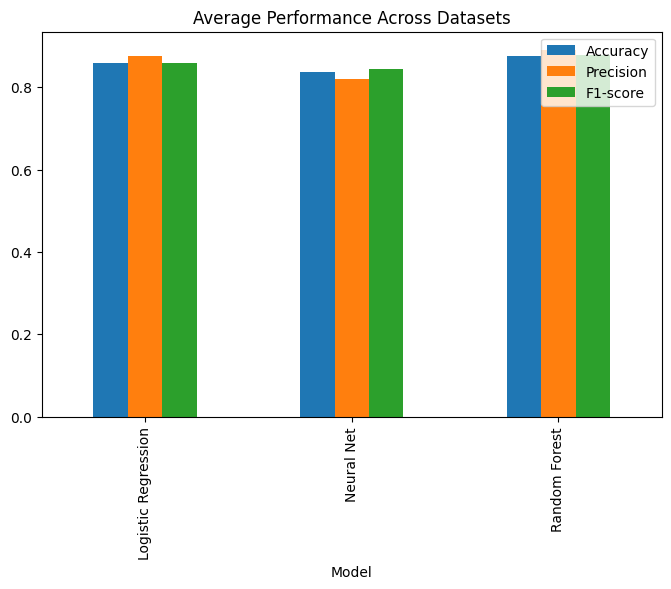

In [ ]:
import matplotlib.pyplot as plt

print("\n📊 Final Model Comparison:")
display(final_results)

final_results.groupby("Model")[["Accuracy", "Precision", "F1-score"]].mean().plot(kind="bar", figsize=(8,5))
plt.title("Average Performance Across Datasets")
plt.show()

# DATA AGUMENTATION


Here we are using backtranslation method it is increased by 25% and 50%

# BIGRAM SMOOTHING

In [ ]:
import pandas as pd
import numpy as np

train = ["I like to see a doll",
         "I like to talk to a kid",
         "kid playing with a doll"]
tt = "<s>I like a kid playing with a doll"

train = [s.lower().split() for s in train]
tt = tt.lower().split()

unique_words = sorted(set(word for s in train for word in s))
print('Unique words:', unique_words)
n = len(unique_words)
print('Vocabulary size:', n)

word_counts = {word: 0 for word in unique_words}
for sentence in train:
    for word in sentence:
        word_counts[word] += 1

print("\nToken counts for each word:", word_counts)

bigram_df = pd.DataFrame(0, index=unique_words, columns=unique_words)

for sentence in train:
    for i in range(len(sentence) - 1):
        current_word = sentence[i]
        next_word = sentence[i + 1]
        bigram_df.loc[current_word, next_word] += 1

print('\nBigram Count Matrix')
print('=' * 80)
print("Row: previous word (wn-1), Column: current word (wn)")
print('-' * 80)
print(bigram_df)

prob_df = pd.DataFrame(index=unique_words, columns=unique_words)
for i in unique_words:
    if word_counts[i] > 0:
        for j in unique_words:
            prob_df.loc[i, j] = bigram_df.loc[i, j] / word_counts[i]

print('\nBigram Probability Matrix')
print('=' * 80)
print("Row: previous word (wn-1), Column: current word (wn)")
print('-' * 80)
print(prob_df.fillna(0).round(3))

print("\nCalculating probability for test sentence:", " ".join(tt))
prob = 1.0
for i in range(len(tt) - 1):
    if tt[i] in unique_words and tt[i + 1] in unique_words:
        prob *= prob_df.loc[tt[i], tt[i + 1]]

print(f"Probability of the test sentence: {prob:.6f}")

k = int(input('Enter the k value: '))
v = len(unique_words)
addk_df = pd.DataFrame(index=unique_words, columns=unique_words)

for i in unique_words:
    for j in unique_words:
        addk_df.loc[i, j] = (bigram_df.loc[i, j] + k) / (word_counts[i] + v)

print('\nAdd-k Smoothing Matrix')
print('=' * 80)
print("Row: previous word (wn-1)+k, Column: current word (wn)+v")
print('-' * 80)
print(addk_df.round(3))

prob1 = 1.0
for i in range(len(tt) - 1):
    if tt[i] in unique_words and tt[i + 1] in unique_words:
        prob1 *= addk_df.loc[tt[i], tt[i + 1]]

print(f"Probability of the test sentence using Add-{k} smoothing: {prob1:.6f}")

wb_df = pd.DataFrame(index=unique_words, columns=unique_words)

for i in unique_words:
    t = (bigram_df.loc[i] > 0).sum()
    z = n - t
    N = word_counts[i]

    for j in unique_words:
        c = bigram_df.loc[i, j]
        if c == 0:
            if z == 0:
                wb_df.loc[i, j] = 0
            else:
                wb_df.loc[i, j] = t / (z * (N + t))
        else:
            wb_df.loc[i, j] = c / (N + t)

print('\nWitten-Bell Discounting Matrix')
print('=' * 80)
print("Row: previous word (wn-1), Column: current word (wn)")
print('-' * 80)
print(wb_df.round(3))

prob2 = 1.0
for i in range(len(tt) - 1):
    if tt[i] in unique_words and tt[i + 1] in unique_words:
        prob2 *= wb_df.loc[tt[i], tt[i + 1]]

print(f"Probability of the test sentence using Witten-Bell discounting: {prob2:.6f}")

filtered_vocab = [word for word in unique_words if word not in ['<s>', '</s>']]

bigram_counts = {}
for word1 in filtered_vocab:
    for word2 in filtered_vocab:
        if bigram_df.loc[word1, word2] > 0:
            bigram_counts[(word1, word2)] = int(bigram_df.loc[word1, word2])
        else:
            bigram_counts[(word1, word2)] = 0

max_count = max(bigram_counts.values())
Nc = {}
for c in range(max_count + 2):
    Nc[c] = sum(1 for count in bigram_counts.values() if count == c)

print('\nGood-Turing Discounting')
print('=' * 80)
print("Frequency counts (Nc):")
for c in sorted(Nc.keys()):
    if Nc[c] > 0:
        print(f"N{c} = {Nc[c]}")

gt_df = pd.DataFrame(0, index=filtered_vocab, columns=filtered_vocab)

N = sum(bigram_counts.values())

print("\nBigram statistics:")
print("Bigram\tC\tNc\tNc+1\tC*\tP*")
print('-' * 60)

for bigram, c in sorted(bigram_counts.items()):
    word1, word2 = bigram
    nc = Nc[c]
    nc_plus_one = Nc.get(c + 1, 0)

    if nc > 0:
        c_star = (c + 1) * (nc_plus_one / nc)
    else:
        c_star = c

    p_star = c_star / N if N > 0 else 0

    gt_df.loc[word1, word2] = p_star

    print(f"{word1}-{word2}\t{c}\t{nc}\t{nc_plus_one}\t{c_star:.3f}\t{p_star:.3f}")

print('\nGood-Turing Probability Matrix')
print('=' * 80)
print("Row: previous word (wn-1), Column: current word (wn)")
print('-' * 80)
print(gt_df.round(3))

prob3 = 1.0
for i in range(len(tt) - 1):
    if tt[i] in filtered_vocab and tt[i + 1] in filtered_vocab:
        prob3 *= gt_df.loc[tt[i], tt[i + 1]]

print(f"Probability of the test sentence using Good-Turing discounting: {prob3:.6f}")

smoothing_probs = {
    "Add-k Smoothing": prob1,
    "Witten-Bell Discounting": prob2,
    "Good-Turing Discounting": prob3
}

best_smoothing = max(smoothing_probs.items(), key=lambda x: x[1])

print("\nComparison of Smoothing Techniques")
print("=" * 80)
print("Technique                  Probability")
print("-" * 80)
for technique, probability in smoothing_probs.items():
    print(f"{technique:<25} {probability:.6f}")
print("\nBest performing smoothing technique:")
print(f"► {best_smoothing[0]} with probability {best_smoothing[1]:.6f}")

/tmp/ipython-input-1804121695.py:55: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  print(prob_df.fillna(0).round(3))


Unique words: ['a', 'doll', 'i', 'kid', 'like', 'playing', 'see', 'talk', 'to', 'with']
Vocabulary size: 10

Token counts for each word: {'a': 3, 'doll': 2, 'i': 2, 'kid': 2, 'like': 2, 'playing': 1, 'see': 1, 'talk': 1, 'to': 3, 'with': 1}

Bigram Count Matrix
Row: previous word (wn-1), Column: current word (wn)
--------------------------------------------------------------------------------
         a  doll  i  kid  like  playing  see  talk  to  with
a        0     2  0    1     0        0    0     0   0     0
doll     0     0  0    0     0        0    0     0   0     0
i        0     0  0    0     2        0    0     0   0     0
kid      0     0  0    0     0        1    0     0   0     0
like     0     0  0    0     0        0    0     0   2     0
playing  0     0  0    0     0        0    0     0   0     1
see      1     0  0    0     0        0    0     0   0     0
talk     0     0  0    0     0        0    0     0   1     0
to       1     0  0    0     0        0    1     1   0 

/tmp/ipython-input-1804121695.py:175: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.006818181818181819' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  gt_df.loc[word1, word2] = p_star
/tmp/ipython-input-1804121695.py:175: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.006818181818181819' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  gt_df.loc[word1, word2] = p_star
/tmp/ipython-input-1804121695.py:175: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.04444444444444444' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  gt_df.loc[word1, word2] = p_star
/tmp/ipython-input-1804121695.py:175: FutureWarning: Setting an item

In [ ]:
def split_train_test():
    """Split pre-cleaned datasets into train/test"""
    datasets = {}

    suicide_df = pd.read_csv("dataset/4_Suicide_Ideation_Dataset.csv", encoding='ISO-8859-1')
    suicide_data = suicide_df['Tweet'].tolist()[:1500]
    datasets['suicide'] = {'train': suicide_data[:1000], 'test': suicide_data[1000:1500]}

    depression_df = pd.read_csv("dataset/1_depression_dataset_reddit_cleaned.csv")
    depression_data = depression_df['clean_text'].tolist()[:1500]
    datasets['depression'] = {'train': depression_data[:1000], 'test': depression_data[1000:1500]}

    stress_df = pd.read_csv('dataset/2_Stress.csv')
    stress_data = stress_df['text'].tolist()[:1500]
    datasets['stress'] = {'train': stress_data[:1000], 'test': stress_data[1000:1500]}

    student_df = pd.read_excel('dataset/3_Student depression and anxiety dataset.xlsx')
    student_data = student_df['text'].tolist()[:1500]
    datasets['student'] = {'train': student_data[:1000], 'test': student_data[1000:1500]}

    return datasets

In [ ]:
def smoothing(train, test_sentences, dataset_name):
    """Perform smoothing analysis using the original code logic"""

    print(f"\n{'='*60}")
    print(f"Dataset: {dataset_name.upper()}")
    print(f"Train: {len(train)}, Test: {len(test_sentences)}")
    print('='*60)

    train = [str(s).lower().split() for s in train if str(s).strip() and str(s) != 'nan']

    unique_words = sorted(set(word for s in train for word in s))
    print('Unique words:', unique_words[:10], '...' if len(unique_words) > 10 else '')
    n = len(unique_words)
    print('Vocabulary size:', n)

    if n == 0:
        print("No vocabulary found!")
        return

    word_counts = {word: 0 for word in unique_words}
    for sentence in train:
        for word in sentence:
            word_counts[word] += 1

    print("\nToken counts for top 5 words:", dict(list(word_counts.items())[:5]))

    bigram_df = pd.DataFrame(0, index=unique_words, columns=unique_words)

    for sentence in train:
        for i in range(len(sentence) - 1):
            current_word = sentence[i]
            next_word = sentence[i + 1]
            bigram_df.loc[current_word, next_word] += 1

    print('\nBigram Count Matrix (first 5x5):')
    print(bigram_df.iloc[:5, :5])

    prob_df = pd.DataFrame(index=unique_words, columns=unique_words)
    for i in unique_words:
        if word_counts[i] > 0:
            for j in unique_words:
                prob_df.loc[i, j] = bigram_df.loc[i, j] / word_counts[i]

    print('\nBigram Probability Matrix (first 5x5):')
    print(prob_df.fillna(0).iloc[:5, :5].round(3))

    tt = test_sentences[0] if test_sentences else "test sentence"
    tt_words = str(tt).lower().split()
    print(f"\nCalculating probability for test sentence: {str(tt)[:50]}...")

    prob = 1.0
    for i in range(len(tt_words) - 1):
        if tt_words[i] in unique_words and tt_words[i + 1] in unique_words:
            prob *= prob_df.loc[tt_words[i], tt_words[i + 1]]
        else:
            prob = 0
            break

    print(f"Probability of the test sentence: {prob:.6f}")

    k = 1
    v = len(unique_words)
    addk_df = pd.DataFrame(index=unique_words, columns=unique_words)

    for i in unique_words:
        for j in unique_words:
            addk_df.loc[i, j] = (bigram_df.loc[i, j] + k) / (word_counts[i] + v)

    print(f'\nAdd-{k} Smoothing Matrix (first 5x5):')
    print(addk_df.iloc[:5, :5].round(3))

    prob1 = 1.0
    for i in range(len(tt_words) - 1):
        if tt_words[i] in unique_words and tt_words[i + 1] in unique_words:
            prob1 *= addk_df.loc[tt_words[i], tt_words[i + 1]]
        else:
            prob1 = 0
            break

    print(f"Probability of the test sentence using Add-{k} smoothing: {prob1:.6f}")

    wb_df = pd.DataFrame(index=unique_words, columns=unique_words)

    for i in unique_words:
        t = (bigram_df.loc[i] > 0).sum()
        z = n - t
        N = word_counts[i]

        for j in unique_words:
            c = bigram_df.loc[i, j]
            if c == 0:
                if z == 0:
                    wb_df.loc[i, j] = 0
                else:
                    wb_df.loc[i, j] = t / (z * (N + t))
            else:
                wb_df.loc[i, j] = c / (N + t)

    print('\nWitten-Bell Discounting Matrix (first 5x5):')
    print(wb_df.iloc[:5, :5].round(3))

    prob2 = 1.0
    for i in range(len(tt_words) - 1):
        if tt_words[i] in unique_words and tt_words[i + 1] in unique_words:
            prob2 *= wb_df.loc[tt_words[i], tt_words[i + 1]]
        else:
            prob2 = 0
            break

    print(f"Probability of the test sentence using Witten-Bell discounting: {prob2:.6f}")

    filtered_vocab = [word for word in unique_words if word not in ['<s>', '</s>']]

    bigram_counts = {}
    for word1 in filtered_vocab:
        for word2 in filtered_vocab:
            if bigram_df.loc[word1, word2] > 0:
                bigram_counts[(word1, word2)] = int(bigram_df.loc[word1, word2])
            else:
                bigram_counts[(word1, word2)] = 0

    max_count = max(bigram_counts.values()) if bigram_counts else 0
    Nc = {}
    for c in range(max_count + 2):
        Nc[c] = sum(1 for count in bigram_counts.values() if count == c)

    print('\nGood-Turing Discounting')
    print("Frequency counts (Nc):")
    for c in sorted(Nc.keys())[:5]:
        if Nc[c] > 0:
            print(f"N{c} = {Nc[c]}")

    gt_df = pd.DataFrame(0, index=filtered_vocab, columns=filtered_vocab)

    N = sum(bigram_counts.values())

    for bigram, c in bigram_counts.items():
        word1, word2 = bigram
        nc = Nc[c]
        nc_plus_one = Nc.get(c + 1, 0)

        if nc > 0:
            c_star = (c + 1) * (nc_plus_one / nc)
        else:
            c_star = c

        p_star = c_star / N if N > 0 else 0
        gt_df.loc[word1, word2] = p_star

    print('\nGood-Turing Probability Matrix (first 5x5):')
    print(gt_df.iloc[:5, :5].round(3))

    prob3 = 1.0
    for i in range(len(tt_words) - 1):
        if tt_words[i] in filtered_vocab and tt_words[i + 1] in filtered_vocab:
            prob3 *= gt_df.loc[tt_words[i], tt_words[i + 1]]
        else:
            prob3 = 0
            break

    print(f"Probability of the test sentence using Good-Turing discounting: {prob3:.6f}")

    smoothing_probs = {
        "Regular Bigram": prob,
        "Add-k Smoothing": prob1,
        "Witten-Bell Discounting": prob2,
        "Good-Turing Discounting": prob3
    }

    best_smoothing = max(smoothing_probs.items(), key=lambda x: x[1])

    print("\nComparison of Smoothing Techniques")
    print("=" * 50)
    print("Technique                  Probability")
    print("-" * 50)
    for technique, probability in smoothing_probs.items():
        print(f"{technique:<25} {probability:.6f}")
    print(f"\nBest performing smoothing technique:")
    print(f"► {best_smoothing[0]} with probability {best_smoothing[1]:.6f}")

In [ ]:
datasets = split_train_test()

smoothing(datasets['suicide']['train'], datasets['suicide']['test'], 'Suicide Ideation')
smoothing(datasets['depression']['train'], datasets['depression']['test'], 'Depression Reddit')
smoothing(datasets['stress']['train'], datasets['stress']['test'], 'Stress')
smoothing(datasets['student']['train'], datasets['student']['test'], 'Student Depression and Anxiety')


Dataset: SUICIDE IDEATION
Train: 1000, Test: 500
Unique words: ['!', '"fuck', '"i', '"let', '"my', '"oh', '"suicide', '"trumpy', '#2', '#30under30'] ...
Vocabulary size: 4882

Token counts for top 5 words: {'!': 9, '"fuck': 1, '"i': 2, '"let': 1, '"my': 1}

Bigram Count Matrix (first 5x5):
       !  "fuck  "i  "let  "my
!      0      0   0     0    0
"fuck  0      0   0     0    0
"i     0      0   0     0    0
"let   0      0   0     0    0
"my    0      0   0     0    0

Bigram Probability Matrix (first 5x5):


/tmp/ipython-input-2850232261.py:51: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  print(prob_df.fillna(0).iloc[:5, :5].round(3))


         !  "fuck   "i  "let  "my
!      0.0    0.0  0.0   0.0  0.0
"fuck  0.0    0.0  0.0   0.0  0.0
"i     0.0    0.0  0.0   0.0  0.0
"let   0.0    0.0  0.0   0.0  0.0
"my    0.0    0.0  0.0   0.0  0.0

Calculating probability for test sentence: i just want to have a friend or a group of friends...
Probability of the test sentence: 0.000000

Add-1 Smoothing Matrix (first 5x5):
              !     "fuck        "i      "let       "my
!      0.000204  0.000204  0.000204  0.000204  0.000204
"fuck  0.000205  0.000205  0.000205  0.000205  0.000205
"i     0.000205  0.000205  0.000205  0.000205  0.000205
"let   0.000205  0.000205  0.000205  0.000205  0.000205
"my    0.000205  0.000205  0.000205  0.000205  0.000205
Probability of the test sentence using Add-1 smoothing: 0.000000

Witten-Bell Discounting Matrix (first 5x5):
              !     "fuck        "i      "let       "my
!      0.000082  0.000082  0.000082  0.000082  0.000082
"fuck  0.000102  0.000102  0.000102  0.000102  0.000102
"i  

Streaming output truncated to the last 5000 lines.
/tmp/ipython-input-2850232261.py:165: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2.5821431647479316e-08' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  gt_df.loc[word1, word2] = p_star
/tmp/ipython-input-2850232261.py:165: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2.5821431647479316e-08' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  gt_df.loc[word1, word2] = p_star
/tmp/ipython-input-2850232261.py:165: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2.5821431647479316e-08' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  gt_df.loc[word1, word2] = p_star
/tmp/ipyth